In [1]:
import os
import json
import math
import re
import sqlite3
import time
from collections import Counter, defaultdict
from typing import Any, TypedDict

import numpy as np
from openai import OpenAI

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise RuntimeError("Set OPENAI_API_KEY before running this notebook: export OPENAI_API_KEY=sk-...")

client = OpenAI(api_key=OPENAI_API_KEY)
EMBED_MODEL = "text-embedding-3-small"
CHAT_MODEL = os.getenv("OPENAI_CHAT_MODEL", "gpt-4o-mini")

print(f"OpenAI ready. Chat model: {CHAT_MODEL}; embedding model: {EMBED_MODEL}")

OpenAI ready. Chat model: gpt-4o-mini; embedding model: text-embedding-3-small


In [2]:
conn = sqlite3.connect(":memory:")

In [3]:
conn.row_factory = sqlite3.Row

In [4]:
conn.executescript("""
CREATE TABLE clusters (cluster_id INTEGER PRIMARY KEY, name TEXT, region TEXT, environment TEXT);
CREATE TABLE incidents (incident_id INTEGER PRIMARY KEY, cluster_id INTEGER, severity TEXT, status TEXT, mttr_minutes INTEGER);
INSERT INTO clusters VALUES (1, 'prod-us-east-1', 'us-east-1', 'prod'), (2, 'prod-eu-west-1', 'eu-west-1', 'prod'), (3, 'dev-us-west-2', 'us-west-2', 'dev');
INSERT INTO incidents VALUES (101, 1, 'P1', 'resolved', 42), (102, 1, 'P2', 'open', 90), (103, 2, 'P1', 'resolved', 55), (104, 2, 'P1', 'open', 120);
""")
SCHEMA = """
clusters(cluster_id, name, region, environment)
incidents(incident_id, cluster_id, severity, status, mttr_minutes)
Relationships: incidents.cluster_id -> clusters.cluster_id
"""
print(SCHEMA)


clusters(cluster_id, name, region, environment)
incidents(incident_id, cluster_id, severity, status, mttr_minutes)
Relationships: incidents.cluster_id -> clusters.cluster_id



In [5]:
def classify_intent(question: str) -> str:
    if re.search(r"\b(how many|count|average|which cluster|mttr|open incidents)\b", question.lower()):
        return "sql"
    return "rag"


In [7]:
def generate_sql(question: str) -> str:
    prompt = f"""Generate one SQLite SELECT query for this schema.
Return only SQL, no markdown.

Schema:
{SCHEMA}

Question: {question}"""
    response = client.chat.completions.create(
        model=CHAT_MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
    )
    return response.choices[0].message.content.strip().strip('`')

In [8]:
def is_select_only(sql: str) -> bool:
    normalized = sql.strip().lower()
    blocked = ["insert", "update", "delete", "drop", "alter", "create", "truncate"]
    return normalized.startswith("select") and not any(re.search(rf"\b{kw}\b", normalized) for kw in blocked)

In [9]:
def execute_sql(sql: str) -> list[dict[str, Any]]:
    return [dict(row) for row in conn.execute(sql).fetchall()]

In [10]:
question = "How many P1 incidents are open by cluster?"
sql = generate_sql(question)
print(sql)

SELECT c.cluster_id, c.name, COUNT(i.incident_id) AS open_p1_incidents
FROM clusters c
JOIN incidents i ON c.cluster_id = i.cluster_id
WHERE i.severity = 'P1' AND i.status = 'open'
GROUP BY c.cluster_id, c.name;


In [11]:
print("SELECT-only:", is_select_only(sql))
if is_select_only(sql):
    print(execute_sql(sql))

SELECT-only: True
[{'cluster_id': 2, 'name': 'prod-eu-west-1', 'open_p1_incidents': 1}]


In [12]:
from langgraph.graph import StateGraph, END

class SQLState(TypedDict):
    question: str
    intent: str
    sql: str
    approved: bool
    rows: list[dict[str, Any]]
    answer: str

In [13]:
def route(state: SQLState) -> SQLState:
    return {**state, "intent": classify_intent(state["question"])}

def make_sql(state: SQLState) -> SQLState:
    return {**state, "sql": generate_sql(state["question"])}

def approve(state: SQLState) -> SQLState:
    approved = is_select_only(state["sql"])
    print("Approval preview:", state["sql"], "approved=", approved)
    return {**state, "approved": approved}

def execute(state: SQLState) -> SQLState:
    rows = execute_sql(state["sql"]) if state["approved"] else []
    return {**state, "rows": rows}

def summarize(state: SQLState) -> SQLState:
    return {**state, "answer": f"Rows: {state['rows']}"}

def next_after_route(state: SQLState) -> str:
    return "make_sql" if state["intent"] == "sql" else "summarize"

In [14]:
g = StateGraph(SQLState)
g.add_node("route", route)
g.add_node("make_sql", make_sql)
g.add_node("approve", approve)
g.add_node("execute", execute)
g.add_node("summarize", summarize)

In [15]:
g.set_entry_point("route")
g.add_conditional_edges("route", next_after_route, {"make_sql": "make_sql", "summarize": "summarize"})
g.add_edge("make_sql", "approve")
g.add_edge("approve", "execute")
g.add_edge("execute", "summarize")
g.add_edge("summarize", END)
sql_graph = g.compile()

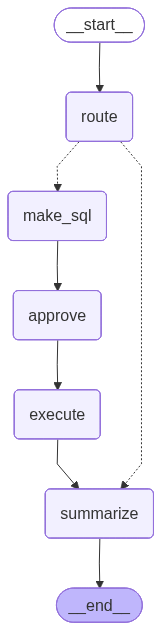

In [16]:
from IPython.display import Image, display


display(Image(sql_graph.get_graph().draw_mermaid_png()))

In [17]:

result = sql_graph.invoke({"question": question, "intent": "", "sql": "", "approved": False, "rows": [], "answer": ""})
print(result["answer"])

Approval preview: SELECT c.cluster_id, c.name, COUNT(i.incident_id) AS open_p1_incidents
FROM clusters c
JOIN incidents i ON c.cluster_id = i.cluster_id
WHERE i.severity = 'P1' AND i.status = 'open'
GROUP BY c.cluster_id, c.name; approved= True
Rows: [{'cluster_id': 2, 'name': 'prod-eu-west-1', 'open_p1_incidents': 1}]
